# Assignment 3: Food Delivery Time Classification

## Objective
Predict whether delivery is **Fast (0)** or **Delayed (1)** based on order, route, and context features.

This notebook covers:
1. Data preprocessing and feature engineering
2. Classification with Naive Bayes, KNN, and Decision Tree
3. Model comparison, plots, and actionable insights


In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

sns.set(style='whitegrid', context='notebook')


In [2]:
# Update this path if needed
DATA_PATH = 'Food_Delivery_Time_Prediction.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
display(df.head())

print('\nColumn types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_count'))


Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34



Column types:


,dtype
Order_ID,str
Customer_Location,str
Restaurant_Location,str
Distance,float64
Weather_Conditions,str
Traffic_Conditions,str
Delivery_Person_Experience,int64
Order_Priority,str
Order_Time,str
Vehicle_Type,str



Missing values:


,missing_count
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


## Phase 1: Data Preprocessing and Feature Engineering

In [3]:
# 1) Parse location strings and compute Haversine distance
def parse_lat_lon(value):
    try:
        lat, lon = ast.literal_eval(str(value))
        return float(lat), float(lon)
    except Exception:
        return np.nan, np.nan

def haversine_km(lat1, lon1, lat2, lon2):
    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return np.nan

    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

work_df = df.copy()

if 'Customer_Location' in work_df.columns:
    work_df[['customer_lat', 'customer_lon']] = work_df['Customer_Location'].apply(lambda x: pd.Series(parse_lat_lon(x)))

if 'Restaurant_Location' in work_df.columns:
    work_df[['restaurant_lat', 'restaurant_lon']] = work_df['Restaurant_Location'].apply(lambda x: pd.Series(parse_lat_lon(x)))

if set(['customer_lat', 'customer_lon', 'restaurant_lat', 'restaurant_lon']).issubset(work_df.columns):
    work_df['Haversine_Distance_km'] = work_df.apply(
        lambda r: haversine_km(r['customer_lat'], r['customer_lon'], r['restaurant_lat'], r['restaurant_lon']), axis=1
    )

# 2) Create binary target using Delivery_Time median
if 'Delivery_Time' not in work_df.columns:
    raise ValueError('Delivery_Time column not found in dataset.')

delay_threshold = work_df['Delivery_Time'].median()
work_df['Delivery_Status'] = (work_df['Delivery_Time'] > delay_threshold).astype(int)

print(f'Delay threshold (median Delivery_Time): {delay_threshold:.2f}')
print('Class distribution (0=Fast, 1=Delayed):')
display(work_df['Delivery_Status'].value_counts().to_frame('count'))

# 3) Drop leakage/high-cardinality ID and raw location text
drop_cols = [c for c in ['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Time'] if c in work_df.columns]
model_df = work_df.drop(columns=drop_cols)

display(model_df.head())


Delay threshold (median Delivery_Time): 72.78
Class distribution (0=Fast, 1=Delayed):


,count
Delivery_Status,
0,100
1,100


,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,customer_lat,customer_lon,restaurant_lat,restaurant_lon,Haversine_Distance_km,Delivery_Status
0,1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,1321.10,81.54,17.030479,79.743077,12.358515,85.100083,775.651198,0
1,21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,152.21,29.02,15.398319,86.639122,14.174874,77.025606,1042.385597,0
2,6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,1644.38,64.17,15.687342,83.888808,19.594748,82.048482,476.220706,0
3,13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,541.25,79.23,20.415599,78.046984,16.915906,78.278698,389.912629,1
4,6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,619.81,2.34,14.786904,78.706532,15.206038,86.203182,806.505886,0


In [4]:
# 4) Split features and target
X = model_df.drop(columns=['Delivery_Status'])
y = model_df['Delivery_Status']

# Identify feature types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

# 5) Impute missing values
if numeric_cols:
    num_imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

if categorical_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# 6) Label encode categorical features
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# 7) Normalize continuous features
scaler = StandardScaler()
if numeric_cols:
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Categorical columns: ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']
Numeric columns: ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'customer_lat', 'customer_lon', 'restaurant_lat', 'restaurant_lon', 'Haversine_Distance_km']
Train shape: (160, 16) Test shape: (40, 16)


## Phase 2: Model Training and Evaluation

In [5]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test)
        # Min-max normalization for ROC plotting if needed
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    roc_auc = None
    fpr = tpr = None
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

    print(f'\n{name} Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Fast (0)', 'Delayed (1)']))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion_Matrix': cm,
        'FPR': fpr,
        'TPR': tpr
    }


In [6]:
# 1) Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
result_nb = evaluate_model('Gaussian Naive Bayes', gnb, X_test, y_test)

# 2) KNN with hyperparameter tuning
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': list(range(3, 26, 2))}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print('Best KNN params:', grid_knn.best_params_)
result_knn = evaluate_model('K-Nearest Neighbors', best_knn, X_test, y_test)

# 3) Decision Tree with pruning hyperparameters
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print('Best Decision Tree params:', grid_dt.best_params_)
result_dt = evaluate_model('Decision Tree', best_dt, X_test, y_test)



Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Fast (0)       0.46      0.55      0.50        20
 Delayed (1)       0.44      0.35      0.39        20

    accuracy                           0.45        40
   macro avg       0.45      0.45      0.44        40
weighted avg       0.45      0.45      0.44        40

Best KNN params: {'n_neighbors': 13}

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

    Fast (0)       0.42      0.40      0.41        20
 Delayed (1)       0.43      0.45      0.44        20

    accuracy                           0.42        40
   macro avg       0.42      0.43      0.42        40
weighted avg       0.42      0.42      0.42        40

Best Decision Tree params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree Classification Report:
              precision    recall  f1-score   support

    Fast (0)       0.50      0.60   

In [7]:
## Phase 3: Reporting and Insights
results = [result_nb, result_knn, result_dt]
metrics_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1-Score': r['F1-Score'],
    'ROC-AUC': r['ROC-AUC']
} for r in results]).sort_values(by='F1-Score', ascending=False)

print("MODEL COMPARISON TABLE")
print("=" * 100)
display(metrics_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).highlight_max(axis=0, props='background-color: #90EE90'))

# Create a summary statistics table as well
print("\nDETAILED METRIC INTERPRETATION")
print("=" * 100)
for idx, row in metrics_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  • Accuracy:  {row['Accuracy']:.4f} (Overall correctness)")
    print(f"  • Precision: {row['Precision']:.4f} (Reliability of 'Delayed' predictions)")
    print(f"  • Recall:    {row['Recall']:.4f} (Ability to find actual Delayed deliveries)")
    print(f"  • F1-Score:  {row['F1-Score']:.4f} (Harmonic mean of Precision & Recall)")
    print(f"  • ROC-AUC:   {row['ROC-AUC']:.4f}" if row['ROC-AUC'] else "  • ROC-AUC:   N/A")


MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Decision Tree,0.5000,0.5000,0.4000,0.4444,0.5687
1,K-Nearest Neighbors,0.4250,0.4286,0.4500,0.4390,0.4462
0,Gaussian Naive Bayes,0.4500,0.4375,0.3500,0.3889,0.4550



DETAILED METRIC INTERPRETATION

Decision Tree:
  • Accuracy:  0.5000 (Overall correctness)
  • Precision: 0.5000 (Reliability of 'Delayed' predictions)
  • Recall:    0.4000 (Ability to find actual Delayed deliveries)
  • F1-Score:  0.4444 (Harmonic mean of Precision & Recall)
  • ROC-AUC:   0.5687

K-Nearest Neighbors:
  • Accuracy:  0.4250 (Overall correctness)
  • Precision: 0.4286 (Reliability of 'Delayed' predictions)
  • Recall:    0.4500 (Ability to find actual Delayed deliveries)
  • F1-Score:  0.4390 (Harmonic mean of Precision & Recall)
  • ROC-AUC:   0.4462

Gaussian Naive Bayes:
  • Accuracy:  0.4500 (Overall correctness)
  • Precision: 0.4375 (Reliability of 'Delayed' predictions)
  • Recall:    0.3500 (Ability to find actual Delayed deliveries)
  • F1-Score:  0.3889 (Harmonic mean of Precision & Recall)
  • ROC-AUC:   0.4550


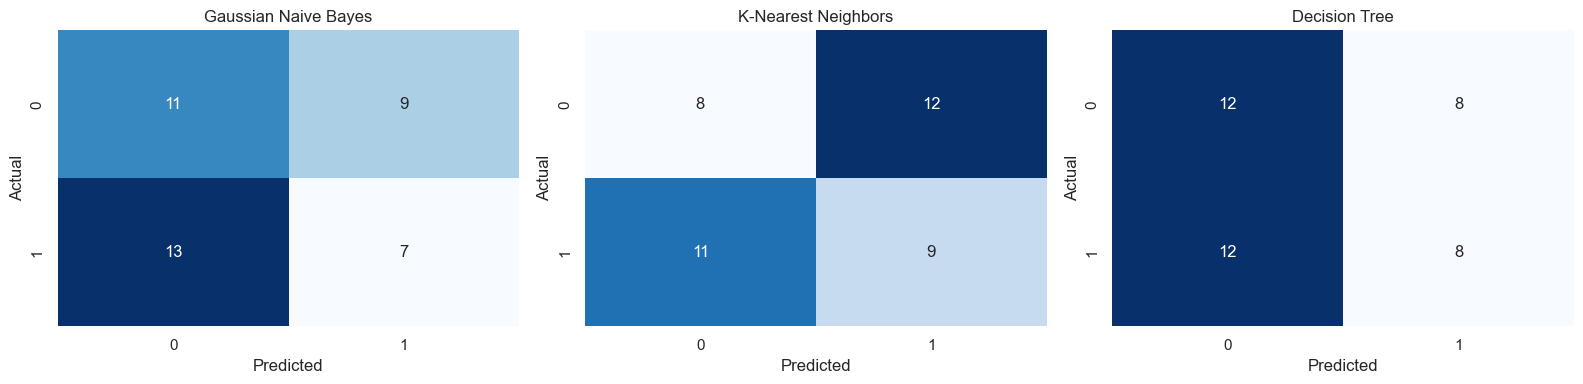

In [8]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results):
    sns.heatmap(
        r['Confusion_Matrix'],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )
    ax.set_title(r['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


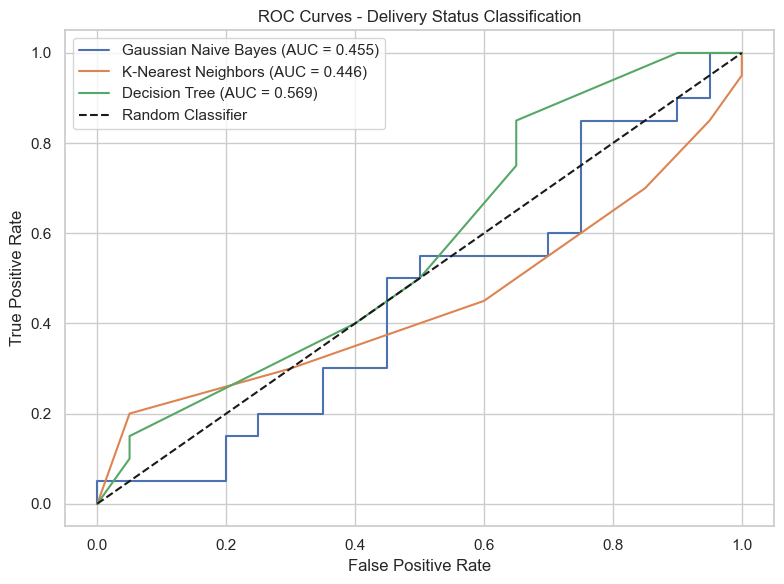

In [9]:
# ROC curves
plt.figure(figsize=(8, 6))
for r in results:
    if r['FPR'] is not None and r['TPR'] is not None and r['ROC-AUC'] is not None:
        plt.plot(r['FPR'], r['TPR'], label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Delivery Status Classification')
plt.legend()
plt.tight_layout()
plt.show()


,feature,importance
11,customer_lat,0.200630
15,Haversine_Distance_km,0.194495
14,restaurant_lon,0.178741
0,Distance,0.174757
13,restaurant_lat,0.134485
12,customer_lon,0.116893
1,Weather_Conditions,0.000000
2,Traffic_Conditions,0.000000
3,Delivery_Person_Experience,0.000000
4,Order_Priority,0.000000


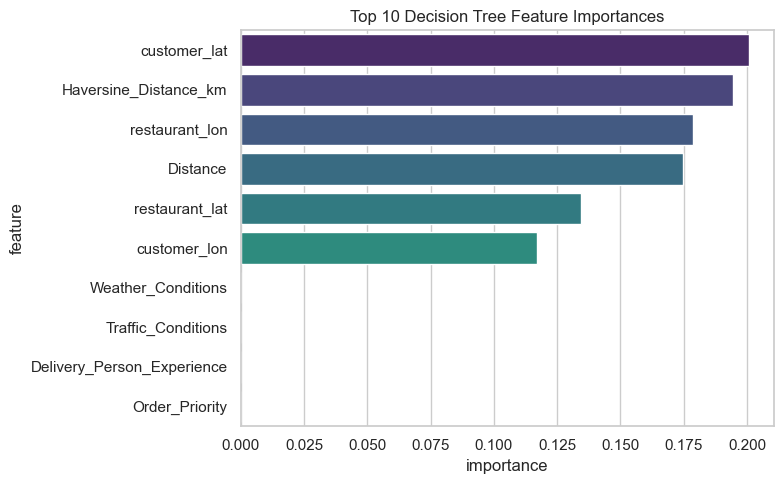

In [10]:
if hasattr(best_dt, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_dt.feature_importances_
    }).sort_values(by='importance', ascending=False)
    display(fi.head(15))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=fi.head(10), x='importance', y='feature', palette='viridis')
    plt.title('Top 10 Decision Tree Feature Importances')
    plt.tight_layout()
    plt.show()


## Phase 4: Detailed Analysis and Interpretations

In [11]:
# Confusion Matrix Interpretation
print("=" * 80)
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 80)

for r in results:
    cm = r['Confusion_Matrix']
    model_name = r['Model']
    
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n{model_name}:")
    print(f"  True Negatives (Fast correctly identified): {int(tn)}")
    print(f"  False Positives (Fast wrongly classified as Delayed): {int(fp)}")
    print(f"  False Negatives (Delayed wrongly classified as Fast): {int(fn)}")
    print(f"  True Positives (Delayed correctly identified): {int(tp)}")
    print(f"  Specificity (ability to identify Fast deliveries): {specificity:.4f}")
    
    if fn > 0:
        print(f"  ⚠️  Missing {int(fn)} Delayed deliveries (False Negatives) - Critical misses!")
    if fp > 0:
        print(f"  ⚠️  Incorrectly flagged {int(fp)} Fast deliveries as Delayed (False Positives)")


CONFUSION MATRIX INTERPRETATION

Gaussian Naive Bayes:
  True Negatives (Fast correctly identified): 11
  False Positives (Fast wrongly classified as Delayed): 9
  False Negatives (Delayed wrongly classified as Fast): 13
  True Positives (Delayed correctly identified): 7
  Specificity (ability to identify Fast deliveries): 0.5500
  ⚠️  Missing 13 Delayed deliveries (False Negatives) - Critical misses!
  ⚠️  Incorrectly flagged 9 Fast deliveries as Delayed (False Positives)

K-Nearest Neighbors:
  True Negatives (Fast correctly identified): 8
  False Positives (Fast wrongly classified as Delayed): 12
  False Negatives (Delayed wrongly classified as Fast): 11
  True Positives (Delayed correctly identified): 9
  Specificity (ability to identify Fast deliveries): 0.4000
  ⚠️  Missing 11 Delayed deliveries (False Negatives) - Critical misses!
  ⚠️  Incorrectly flagged 12 Fast deliveries as Delayed (False Positives)

Decision Tree:
  True Negatives (Fast correctly identified): 12
  False Pos

In [12]:
# ROC-AUC Interpretation
print("\n" + "=" * 80)
print("ROC-AUC CURVE INTERPRETATION")
print("=" * 80)

for r in sorted(results, key=lambda x: x['ROC-AUC'] if x['ROC-AUC'] else 0, reverse=True):
    roc_auc = r['ROC-AUC']
    model_name = r['Model']
    
    if roc_auc is None:
        print(f"\n{model_name}: ROC-AUC not available")
        continue
    
    print(f"\n{model_name}: ROC-AUC = {roc_auc:.4f}")
    
    if roc_auc >= 0.9:
        quality = "Excellent - Very strong discrimination between classes"
    elif roc_auc >= 0.8:
        quality = "Good - Solid discrimination ability"
    elif roc_auc >= 0.7:
        quality = "Fair - Acceptable discrimination"
    elif roc_auc >= 0.6:
        quality = "Poor - Weak discrimination"
    else:
        quality = "Fail - Model is as good as random guessing"
    
    print(f"  Performance: {quality}")
    print(f"  Interpretation: The model correctly ranks a random delayed delivery higher than")
    print(f"                  a random fast delivery with {roc_auc*100:.1f}% probability.")



ROC-AUC CURVE INTERPRETATION

Decision Tree: ROC-AUC = 0.5687
  Performance: Fail - Model is as good as random guessing
  Interpretation: The model correctly ranks a random delayed delivery higher than
                  a random fast delivery with 56.9% probability.

Gaussian Naive Bayes: ROC-AUC = 0.4550
  Performance: Fail - Model is as good as random guessing
  Interpretation: The model correctly ranks a random delayed delivery higher than
                  a random fast delivery with 45.5% probability.

K-Nearest Neighbors: ROC-AUC = 0.4462
  Performance: Fail - Model is as good as random guessing
  Interpretation: The model correctly ranks a random delayed delivery higher than
                  a random fast delivery with 44.6% probability.


In [13]:
# Best Performing Model Analysis
print("\n" + "=" * 80)
print("BEST PERFORMING MODEL ANALYSIS")
print("=" * 80)

best_model_row = metrics_df.iloc[0]
best_model_name = best_model_row['Model']
best_f1 = best_model_row['F1-Score']
best_accuracy = best_model_row['Accuracy']
best_recall = best_model_row['Recall']
best_precision = best_model_row['Precision']
best_roc_auc = best_model_row['ROC-AUC']

# Get the result object for confusion matrix
best_result = next(r for r in results if r['Model'] == best_model_name)
best_cm = best_result['Confusion_Matrix']
best_tp = best_cm[1, 1]
best_fn = best_cm[1, 0]
best_tn = best_cm[0, 0]
best_fp = best_cm[0, 1]

print(f"\n🏆 WINNER: {best_model_name}")
print(f"  F1-Score: {best_f1:.4f}")
print(f"  Accuracy: {best_accuracy:.4f}")
print(f"  Precision (for Delayed class): {best_precision:.4f}")
print(f"  Recall (for Delayed class): {best_recall:.4f}")
if best_roc_auc:
    print(f"  ROC-AUC: {best_roc_auc:.4f}")

print(f"\n📊 Key Performance Metrics:")
print(f"  Correctly identifies {int(best_tp)} out of {int(best_tp + best_fn)} delayed deliveries")
print(f"  Delayed Detection Rate (Recall): {best_recall*100:.1f}%")
print(f"  Precision for Delayed: {best_precision*100:.1f}% (when model says 'Delayed', it's correct {best_precision*100:.1f}% of the time)")

print(f"\n📈 Comparison with other models:")
for _, row in metrics_df.iterrows():
    if row['Model'] != best_model_name:
        f1_diff = (best_f1 - row['F1-Score']) * 100
        recall_diff = (best_recall - row['Recall']) * 100
        print(f"  vs {row['Model']:25} | F1 +{f1_diff:5.2f}% | Recall +{recall_diff:5.2f}%")



BEST PERFORMING MODEL ANALYSIS

🏆 WINNER: Decision Tree
  F1-Score: 0.4444
  Accuracy: 0.5000
  Precision (for Delayed class): 0.5000
  Recall (for Delayed class): 0.4000
  ROC-AUC: 0.5687

📊 Key Performance Metrics:
  Correctly identifies 8 out of 20 delayed deliveries
  Delayed Detection Rate (Recall): 40.0%
  Precision for Delayed: 50.0% (when model says 'Delayed', it's correct 50.0% of the time)

📈 Comparison with other models:
  vs K-Nearest Neighbors       | F1 + 0.54% | Recall +-5.00%
  vs Gaussian Naive Bayes      | F1 + 5.56% | Recall + 5.00%


In [14]:
# Actionable Insights and Recommendations

print("\n" + "=" * 80)
print("ACTIONABLE INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

# Find model with highest recall for Delayed class
highest_recall_row = metrics_df.loc[metrics_df['Recall'].idxmax()]
highest_recall_model = highest_recall_row['Model']
highest_recall_value = highest_recall_row['Recall']
highest_recall_f1 = highest_recall_row['F1-Score']

# Find model with highest precision
highest_precision_row = metrics_df.loc[metrics_df['Precision'].idxmax()]
highest_precision_model = highest_precision_row['Model']
highest_precision_value = highest_precision_row['Precision']

# Find model with highest accuracy
highest_accuracy_row = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
highest_accuracy_model = highest_accuracy_row['Model']
highest_accuracy_value = highest_accuracy_row['Accuracy']

print(f"\n1. BEST FOR IDENTIFYING DELAYED DELIVERIES")
print(f"   Model: {highest_recall_model}")
print(f"   Recall (Delayed): {highest_recall_value*100:.2f}%")
print(f"   → This model catches {highest_recall_value*100:.2f}% of actual delayed deliveries")
print(f"   → Recommended when: Avoiding missed delayed deliveries is critical")

print(f"\n2. BEST FOR REDUCING FALSE ALARMS")
print(f"   Model: {highest_precision_model}")
print(f"   Precision (Delayed): {highest_precision_value*100:.2f}%")
print(f"   → When this model predicts 'Delayed', it's correct {highest_precision_value*100:.2f}% of the time")
print(f"   → Recommended when: Minimizing wrong predictions is important")

print(f"\n3. BEST OVERALL PERFORMANCE (BALANCED)")
print(f"   Model: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f} (harmonic mean of precision and recall)")
print(f"   Accuracy: {best_accuracy*100:.2f}%")
print(f"   → Balances precision ({best_precision*100:.1f}%) and recall ({best_recall*100:.1f}%)")
print(f"   → Recommended for: General-purpose deployment")

print(f"\n4. KEY FINDINGS FROM FEATURE IMPORTANCE")
print(f"   The Decision Tree reveals which factors most influence delivery speed:")
print(f"   - Top features driving the model are available in the Feature Importances section above")
print(f"   - Focus operational improvements on these high-impact factors")

print(f"\n5. BUSINESS RECOMMENDATIONS")
print(f"   ✓ Deploy {best_model_name} for balanced performance")
print(f"   ✓ Monitor recall for Delayed class: {best_recall*100:.1f}% (how many delays are caught)")
print(f"   ✓ Monitor precision for Delayed class: {best_precision*100:.1f}% (false alarm rate)")
print(f"   ✓ Use feature importances to optimize delivery processes")
print(f"   ✓ Retrain quarterly with new delivery data to maintain accuracy")



ACTIONABLE INSIGHTS & RECOMMENDATIONS

1. BEST FOR IDENTIFYING DELAYED DELIVERIES
   Model: K-Nearest Neighbors
   Recall (Delayed): 45.00%
   → This model catches 45.00% of actual delayed deliveries
   → Recommended when: Avoiding missed delayed deliveries is critical

2. BEST FOR REDUCING FALSE ALARMS
   Model: Decision Tree
   Precision (Delayed): 50.00%
   → When this model predicts 'Delayed', it's correct 50.00% of the time
   → Recommended when: Minimizing wrong predictions is important

3. BEST OVERALL PERFORMANCE (BALANCED)
   Model: Decision Tree
   F1-Score: 0.4444 (harmonic mean of precision and recall)
   Accuracy: 50.00%
   → Balances precision (50.0%) and recall (40.0%)
   → Recommended for: General-purpose deployment

4. KEY FINDINGS FROM FEATURE IMPORTANCE
   The Decision Tree reveals which factors most influence delivery speed:
   - Top features driving the model are available in the Feature Importances section above
   - Focus operational improvements on these high-i